# 列表和元组

本节结束后您将能够回答的问题
- 列表和元组有什么用？
- 列表/元组中的查找有多复杂？
- 这种复杂性是如何实现的？
- 列表和元组有什么区别？
- 附加到列表是如何工作的？
- 我应该什么时候使用列表和元组？

在编写高效的程序时，最重要的事情之一就是理解所使用的数据结构。事实上，性能编程的很大一部分是了解您试图对数据提出的问题，并选择能够快速回答这些问题的数据结构。在本节中，我们将讨论列表和元组可以快速回答的问题，以及它们是如何做到的。

列表和元组是一类称为数组的数据结构。数组是具有某种内在顺序的数据的平面列表。通常在这类数据结构中，元素的相对顺序与元素本身一样重要！此外，这种排序的先验知识非常有价值：通过知道数组中的数据位于特定位置，我们可以在O（1）中检索到它！1实现阵列的方法也很多，每个解决方案都有自己有用的特性和保证。这就是为什么在Python中我们有两种类型的数组：列表和元组。列表是动态数组，允许我们修改和调整存储的数据大小，而元组是静态数组，其内容是固定不变的。

让我们把前面的这些陈述整理一下。计算机上的系统内存可以看作是一系列带编号的存储桶，每个存储桶都能存储一个数字。Python通过引用将数据存储在这些bucket中，这意味着数字本身只是指向或引用我们实际关心的数据。因此，这些bucket可以存储我们想要的任何类型的数据（与numpy数组相反，numpy数组具有静态类型，并且只能存储该类型的数据）

当我们想要创建一个数组（以及一个列表或元组）时，我们首先要分配一个系统内存块（这个块的每个部分都将被用作指向实际数据的整数大小的指针）。这涉及到转到系统内核并请求使用N个连续的bucket。下图显示了大小为6的数组（在本例中为列表）的系统内存布局示例。

注意

在Python中，列表还存储它们的大小，因此在分配的6个块中，只有5个可用，第0个元素是长度。

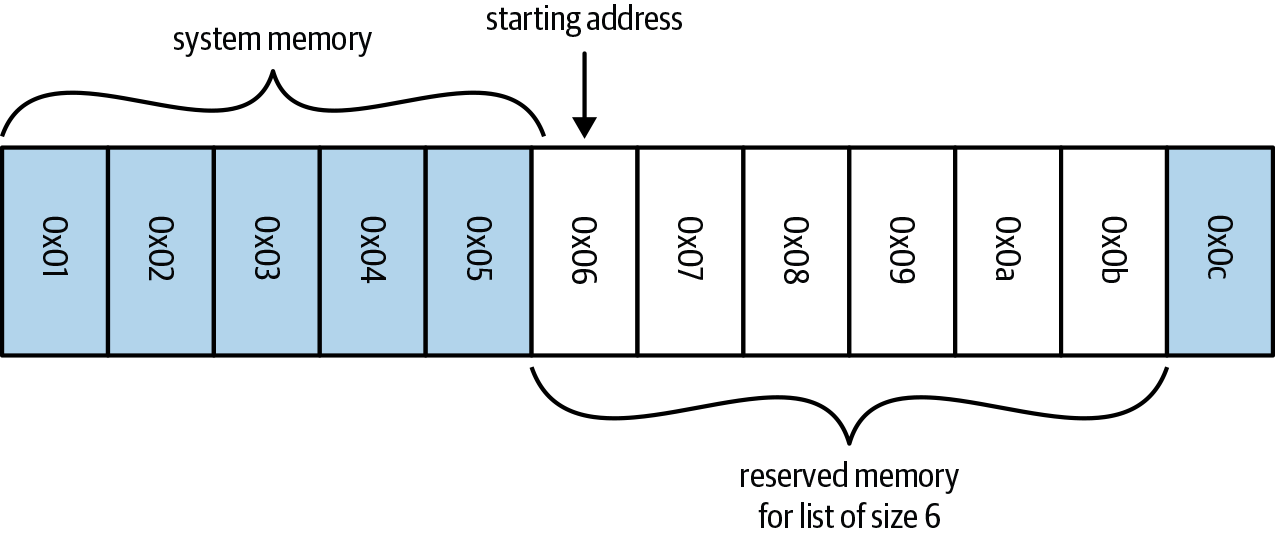

图。大小为6的数组的系统内存布局示例

为了在我们的列表中查找任何特定的元素，我们只需要知道我们想要哪个元素，并记住我们的数据从哪个bucket开始。由于所有的数据都将占用相同的空间（一个“bucket”，或者更具体地说，一个指向实际数据的整数大小的指针），所以我们不需要知道任何关于正在存储的数据类型的信息来执行此计算。

例如，如果我们需要检索数组中的第0个元素，我们只需转到序列中的第一个bucket M，并读取其中的值。另一方面，如果我们需要数组中的第五个元素，我们会去M+5位置的bucket读取它的内容。一般来说，如果我们想从数组中检索元素i，就转到bucket M+i。因此，通过将数据存储在连续的存储桶中，并了解数据的顺序，我们可以通过在一个步骤（或O（1））中知道要查看哪个存储桶来定位数据，而不管数组有多大（例如 3-1).

例3-1。在不同大小的列表中查找的计时

In [5]:
%%timeit l = list(range(10))
l[5]

The slowest run took 28.17 times longer than the fastest. This could mean that an intermediate result is being cached 
10000000 loops, best of 5: 35.6 ns per loop


In [6]:
%%timeit l = list(range(10_000_000))
l[100_000]

The slowest run took 73.49 times longer than the fastest. This could mean that an intermediate result is being cached 
10000000 loops, best of 5: 31.9 ns per loop


如果我们得到一个顺序未知的数组，并且想要检索一个特定的元素呢？如果顺序是已知的，我们可以简单地查找特定的值。但是，在这种情况下，我们必须执行搜索操作。解决这个问题的最基本方法称为线性搜索，我们迭代数组中的每个元素，并检查它是否是我们想要的值，如示例所示 3-2.

例3-2。对列表的线性搜索

In [8]:
import timeit


def linear_search(needle, array):
    for i, item in enumerate(array):
        if item == needle:
            return i
    return -1


if __name__ == "__main__":
    setup = "from __main__ import (linear_search, haystack, needle)"
    iterations = 1000

    for haystack_size in (10000, 100000, 1000000):
        haystack = range(haystack_size)
        for needle in (1, 6000, 9000, 1000000):
            index = linear_search(needle, haystack)
            t = timeit.timeit(
                stmt="linear_search(needle, haystack)", setup=setup, number=iterations
            )
            print(
                f"Value {needle: <8} found in haystack of "
                f"size {len(haystack): <8} at index "
                f"{index: <8} in {t/iterations:.5e} seconds"
            )

Value 1        found in haystack of size 10000    at index 1        in 9.67080e-07 seconds
Value 6000     found in haystack of size 10000    at index 6000     in 6.58437e-04 seconds
Value 9000     found in haystack of size 10000    at index 9000     in 9.50971e-04 seconds
Value 1000000  found in haystack of size 10000    at index -1       in 1.05571e-03 seconds
Value 1        found in haystack of size 100000   at index 1        in 5.10152e-07 seconds
Value 6000     found in haystack of size 100000   at index 6000     in 6.30755e-04 seconds
Value 9000     found in haystack of size 100000   at index 9000     in 9.57171e-04 seconds
Value 1000000  found in haystack of size 100000   at index -1       in 9.86225e-03 seconds
Value 1        found in haystack of size 1000000  at index 1        in 4.70987e-07 seconds
Value 6000     found in haystack of size 1000000  at index 6000     in 5.72714e-04 seconds
Value 9000     found in haystack of size 1000000  at index 9000     in 8.64400e-04 seconds

该算法的最坏情况性能为O（n）。当我们搜索数组中不存在的内容时，就会出现这种情况。为了知道我们要搜索的元素不在数组中，我们必须首先对照其他元素检查它。最终，我们将得到最终的return-1语句。实际上，这个算法正是list.index（）使用的算法。

提高速度的唯一方法是通过对数据如何放置在内存中，或者对我们所持有的数据桶的排列有一些其他的理解。例如，哈希表（“字典和集合是如何工作的？”），方法是为插入/检索增加额外的开销，并强制对项进行严格而特殊的排序。或者，如果对数据进行排序，使每个项都比左边（或右边）的相邻项大（或小），则可以使用专门的搜索算法，将查找时间减少到O（logn）。从我们之前看到的固定时间查找中，这似乎是一个不可能的步骤，但有时这是最好的选择（特别是因为搜索算法更灵活，允许您以创造性的方式定义搜索）。

## 更有效的搜索

如前所述，如果我们首先对数据进行排序，使某个特定项左侧的所有元素都比该项小（或大），则可以获得更好的搜索性能。比较是通过对象的 `__eq__` 和 `__lt__` 。

两个必要的组成部分是排序算法和搜索算法。Python列表有一个使用Tim排序的内置排序算法。Tim sort可以在最佳情况下对O（n）中的列表进行排序（在最坏情况下对O（n logn）中的列表进行排序）。它通过使用多种类型的排序算法并使用启发式算法来猜测给定数据时哪种算法的性能最好（更具体地说，它混合了插入和合并排序算法）来实现这一性能。

一旦一个列表被排序，我们就可以使用二进制搜索找到我们想要的元素（例如 3-3），其平均大小写复杂度为O（logn）。它通过首先查看列表的中间并将该值与所需值进行比较来实现这一点。如果这个中点的值小于我们想要的值，我们考虑列表的右半部分，我们继续像这样对半列表，直到找到值，或者直到知道值不出现在排序的列表中。因此，我们不需要像线性搜索那样读取列表中的所有值；相反，我们只读取其中的一小部分。

例3-3。通过排序列表二进制搜索实现高效搜索

In [9]:
import timeit


def binary_search(needle, haystack):
    # imin and imax store the bounds of the haystack that we are currently
    # considering.  This starts as the bounds of the haystack and slowly
    # converges to surround the needle.
    imin, imax = 0, len(haystack)
    while True:
        if imin >= imax:
            return -1
        midpoint = (imin + imax) // 2
        if haystack[midpoint] > needle:
            imax = midpoint
        elif haystack[midpoint] < needle:
            imin = midpoint + 1
        else:
            return midpoint


if __name__ == "__main__":
    setup = "from __main__ import (binary_search, haystack, needle)"
    iterations = 10000

    for haystack_size in (10000, 100000, 1000000):
        haystack = range(haystack_size)
        for needle in (1, 6000, 9000, 1000000):
            index = binary_search(needle, haystack)
            t = timeit.timeit(
                stmt="binary_search(needle, haystack)", setup=setup, number=iterations
            )
            print(
                f"Value {needle: <8} found in haystack of "
                f"size {len(haystack): <8} at index "
                f"{index: <8} in {t/iterations:.5e} seconds"
            )

Value 1        found in haystack of size 10000    at index 1        in 4.42323e-06 seconds
Value 6000     found in haystack of size 10000    at index 6000     in 6.08447e-06 seconds
Value 9000     found in haystack of size 10000    at index 9000     in 5.98244e-06 seconds
Value 1000000  found in haystack of size 10000    at index -1       in 8.28710e-06 seconds
Value 1        found in haystack of size 100000   at index 1        in 5.38455e-06 seconds
Value 6000     found in haystack of size 100000   at index 6000     in 8.27096e-06 seconds
Value 9000     found in haystack of size 100000   at index 9000     in 7.38867e-06 seconds
Value 1000000  found in haystack of size 100000   at index -1       in 1.10242e-05 seconds
Value 1        found in haystack of size 1000000  at index 1        in 6.32833e-06 seconds
Value 6000     found in haystack of size 1000000  at index 6000     in 8.08150e-06 seconds
Value 9000     found in haystack of size 1000000  at index 9000     in 9.37746e-06 seconds

这种方法允许我们在列表中查找元素，而不必求助于字典中可能很重的解决方案。当对正在操作的数据列表进行本质排序时，尤其如此。在列表上进行二进制搜索以查找对象比将数据转换为字典然后在其上进行查找更有效。尽管字典查找只需要O（1），但将数据转换为字典需要O（n）（并且字典对没有重复键的限制可能是不需要的）。另一方面，二进制搜索将采用O（logn）。

另外，Python标准库中的对分模块简化了这个过程，除了使用高度优化的二进制搜索查找元素外，还提供了简单的方法将元素添加到列表中，同时保持其排序。它通过提供替代函数将元素添加到正确的排序位置来实现这一点。随着列表总是被排序，我们可以很容易地找到我们正在寻找的元素（这方面的例子可以在对分模块的文档中找到）。此外，我们可以使用二分法很快找到最接近我们正在寻找的元素（例如 3-4). 这对于比较两个相似但不完全相同的数据集非常有用。

例3-4。使用对分模块在列表中查找闭合值

In [10]:
import bisect
import random


def find_closest(haystack, needle):
    # bisect.bisect_left will return the first value in the haystack
    # that is greater than the needle
    i = bisect.bisect_left(haystack, needle)
    if i == len(haystack):
        return i - 1
    elif haystack[i] == needle:
        return i
    elif i > 0:
        j = i - 1
        # since we know the value is larger than needle (and vice versa for the
        # value at j), we don't need to use absolute values here
        if haystack[i] - needle > needle - haystack[j]:
            return j
    return i


if __name__ == "__main__":
    important_numbers = []
    for i in range(10):
        new_number = random.randint(0, 1000)
        bisect.insort(important_numbers, new_number)

    # important_numbers will already be in order because we inserted new elements
    # with bisect.insort
    print(important_numbers)
    # > [14, 265, 496, 661, 683, 734, 881, 892, 973, 992]

    closest_index = find_closest(important_numbers, -250)
    print(f"Closest value to -250: {important_numbers[closest_index]}")
    # > Closest value to -250: 14

    closest_index = find_closest(important_numbers, 500)
    print(f"Closest value to 500: {important_numbers[closest_index]}")
    # > Closest value to 500: 496

    closest_index = find_closest(important_numbers, 1100)
    print(f"Closest value to 1100: {important_numbers[closest_index]}")
    # > Closest value to 1100: 992


[191, 213, 569, 578, 579, 595, 657, 677, 796, 943]
Closest value to -250: 191
Closest value to 500: 569
Closest value to 1100: 943


一般来说，这涉及到编写高效代码的一个基本规则：选择正确的数据结构并坚持它！尽管对于特定的操作可能有更有效的数据结构，但是转换到这些数据结构的成本可能会抵消任何效率提升。

## 列表与元组

如果列表和元组都使用相同的底层数据结构，那么两者之间的区别是什么？综上所述，主要区别如下：
- 列表是动态数组；它们是可变的，并允许调整大小（更改所保存的元素的数量）。
- 元组是静态数组；它们是不可变的，并且在创建它们之后，其中的数据不能更改。
- 元组由Python运行时缓存，这意味着我们不需要每次使用元组时都通过与内核通信来保留内存。

这些差异概括了这两者之间的哲学差异：元组用于描述一个不变事物的多个属性，而列表可用于存储关于完全不同对象的数据集合。例如，电话号码的各个部分对于元组来说是完美的：它们不会更改，如果更改，则表示一个新对象或不同的电话号码。类似地，多项式的系数适合一个元组，因为不同的系数代表不同的多项式。另一方面，目前正在阅读这本书的人的名字更适合列一个清单：数据在内容和大小上都在不断变化，但始终代表着相同的想法。

需要注意的是，列表和元组都可以采用混合类型。正如您将看到的，这会引入相当多的开销，并减少一些潜在的优化。如果我们强制所有数据都是同一类型的，那么可以消除这种开销。后面我们将讨论使用numpy来减少所使用的内存和计算开销。此外，像标准库模块数组这样的工具可以减少其他非数字情况下的开销。这暗示了性能编程中的一个要点，我们将在后面的章节中讨论：泛型代码将比专门为解决特定问题而设计的代码慢得多。

此外，元组相对于列表的不变性（可以调整大小和更改大小）使其成为轻量级数据结构。这意味着在存储元组时内存中没有太多开销，对元组的操作非常简单。对于列表，正如您将了解到的，它们的易变性是以存储它们所需的额外内存和使用它们时所需的额外计算为代价的。

练习：

对于下面的示例数据集，您是使用元组还是列表？为什么？
1. 前20个素数
2. 编程语言名称
3. 一个人的年龄、体重和身高
4. 一个人的生日和出生地
5. 一个特定的游泳池比赛的结果
6. 连续一系列台球比赛的结果

提示：
1. 元组，因为数据是静态的，不会改变。
2. 列表，因为这个数据集在不断增长。
3. 列表，因为值需要更新。
4. 元组，因为该信息是静态的，不会更改。
5. 元组，因为数据是静态的。
6. 列表，因为会有更多的游戏(事实上，我们可以使用一个元组列表，因为每个游戏的结果不会改变，但我们需要随着游戏的增多添加更多的结果。）

### 列表为动态数组

创建列表后，我们可以根据需要自由更改其内容：

In [1]:
numbers = [5, 8, 1, 3, 2, 6]
numbers[2] = 2 * numbers[0] #如前所述，这个操作是O（1），因为我们可以立即找到存储在第0和第2个元素中的数据。
numbers

[5, 8, 10, 3, 2, 6]

此外，我们还可以将新数据附加到列表中并扩大其大小：

In [2]:
len(numbers)

6

In [3]:
numbers.append(42)
numbers

[5, 8, 10, 3, 2, 6, 42]

In [4]:
len(numbers)

7

这是可能的，因为动态数组支持调整大小操作，从而增加了数组的容量。当一个大小为N的列表第一次被追加时，Python必须创建一个新的列表，该列表除了要追加的额外列表外，还必须足够大以容纳原来的N个项。然而，不是分配N+1个项目，而是实际分配M个项目，其中M>N，以便为将来的附件提供额外的净空。然后将旧列表中的数据复制到新列表中，并销毁旧列表。

其原理是，一个附加可能是许多附加的开始，通过请求额外的空间，我们可以减少必须发生这种分配的次数，从而减少所需的内存拷贝总数。这一点很重要，因为内存拷贝可能非常昂贵，尤其是当列表大小开始增长时。下图显示了在Python3.7中这种过度分配的情况。例子中给出了这个增长的图。

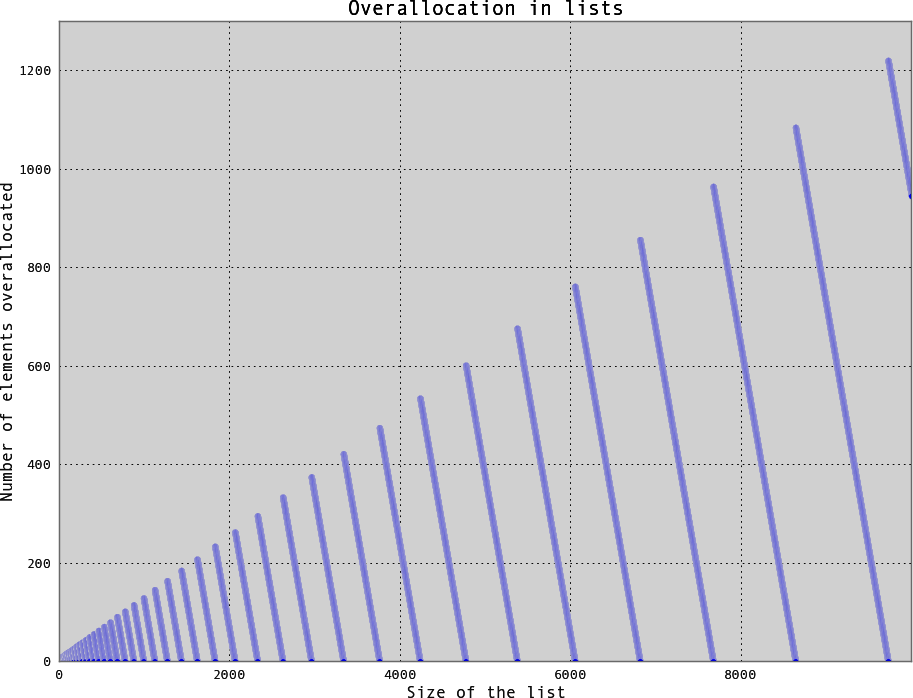

显示分配给特定大小列表的额外元素数的图形。例如，如果使用appends创建一个包含8000个元素的列表，Python将为大约8600个元素分配空间，超过了600个元素！

例3-5。python3.7中的列表分配公式：

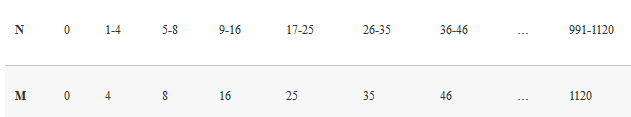

当我们附加数据时，我们利用额外的空间并增加列表的有效大小N。结果，N随着我们添加新数据而增长，直到N==M。在这一点上，没有多余的空间来插入新数据，我们必须创建一个具有更多额外空间的新列表。这个新列表有额外的净空，如示例中的等式所示 我们把旧数据复制到新空间。

图1直观地显示了这一系列事件 3-3. 该图显示了示例中对列表l执行的各种操作 3-6.

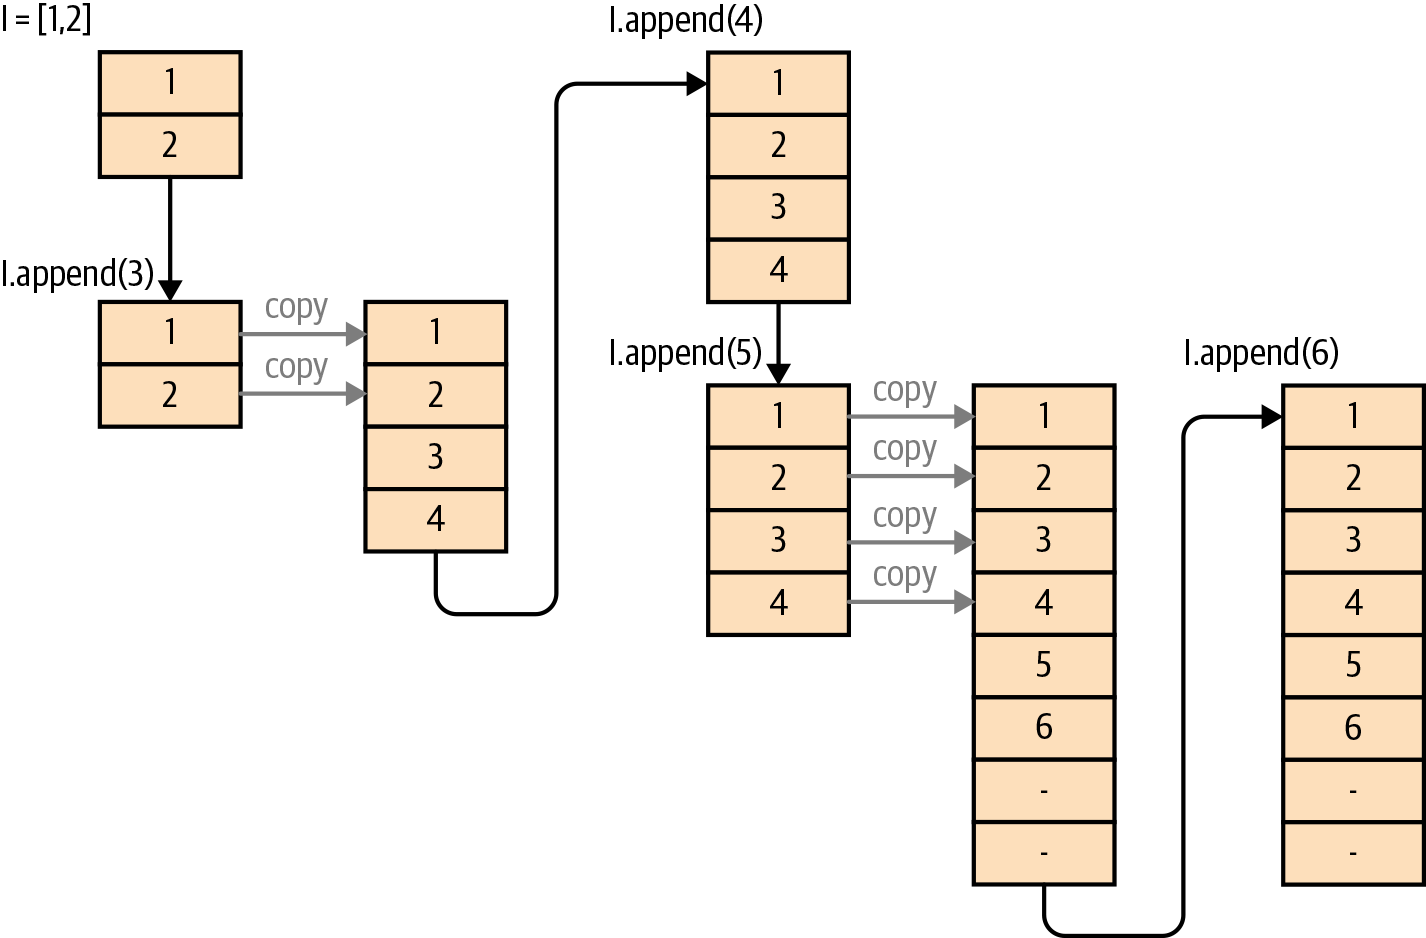

例3-6:调整列表大小

In [5]:
l = [1, 2]
for i in range(3, 7):
    l.append(i)

虽然分配的额外净空量通常很小，但可以加起来。在示例中 3-7，我们可以看到，即使对于100000个元素，我们也使用2.7× 内存，通过建立带有附件的列表来记忆与列表理解：

例3-7。append 对列表理解的内存和时间影响

In [12]:
%memit [i*i for i in range(100_000)]

ERROR: Line magic function `%memit` not found.


In [13]:
%%memit l = []
for i in range(100_000):
    l.append(i * 2)

ERROR: Cell magic `%%memit` not found.


In [14]:
%timeit [i*i for i in range(100_000)]

100 loops, best of 5: 10.6 ms per loop


In [15]:
%%timeit l = []
for i in range(100_000):
    l.append(i * 2)

100 loops, best of 5: 15.4 ms per loop


由于必须运行额外的Python语句以及重新分配内存的成本，整个运行时也比较慢。当您维护许多小列表或保存一个特别大的列表时，这种效果会特别明显。如果我们存储1000000个列表，每个列表包含10个元素，我们会假设10000000个元素的内存正在被使用。然而，实际上，如果使用append操作符构造列表，最多可以分配16000000个元素。类似地，对于100000000个元素的大列表，我们实际分配了112500007个元素！

### 元组作为静态数组

元组是固定不变的。这意味着一旦创建元组，与列表不同的是，它不能被修改或调整大小：

In [16]:
t = (1, 2, 3, 4)
t[0] = 5

TypeError: 'tuple' object does not support item assignment

不过，尽管它们不支持调整大小，但我们可以将两个元组连接在一起并形成一个新元组。此操作类似于列表上的调整大小操作，但我们不会为生成的元组分配任何额外空间：

In [17]:
t1 = (1, 2, 3, 4)
t2 = (5, 6, 7, 8)
t1 + t2

(1, 2, 3, 4, 5, 6, 7, 8)

如果我们认为这与列表上的append操作相当，我们会看到它的执行速度是O（n），而不是列表的O（1）速度。这是因为我们必须在每次向元组添加内容时分配和复制元组，而不是只在列表的额外净空用完时才分配和复制元组。因此，不存在类似于append的就地操作；添加两个元组总是返回内存中新位置的新元组。

不存储用于调整大小的额外净空的好处是使用更少的资源。使用任何append操作创建的大小为100000000的列表实际上使用112500007个元素的内存，而保存相同数据的元组只会使用100000000个元素的内存。这使得元组变得轻量级，并且在数据变为静态时更可取。

此外，即使我们创建一个没有append的列表（因此我们没有append操作引入的额外净空），它在内存中仍然比具有相同数据的元组大。这是因为列表必须跟踪有关其当前状态的更多信息，以便有效地调整大小。虽然这些额外的信息非常小（相当于一个额外的元素），但如果有几百万个列表在使用，这些信息就可以累加起来。

元组的静态特性的另一个好处是Python在后台做的事情：资源缓存。Python是垃圾收集的，这意味着当一个变量不再使用时，Python会释放该变量所使用的内存，将其返回给操作系统，以便在其他应用程序（或其他变量）中使用。但是，对于大小为1到20的元组，当它们不再使用时，空间不会立即返回给系统：每个大小最多可以保存20000个以备将来使用。这意味着，当将来需要一个这样大小的新元组时，我们不需要与操作系统通信来在内存中找到一个区域来将数据放入，因为我们已经有了一个可用内存储备。但是，这也意味着Python进程将有一些额外的内存开销。

虽然这似乎是一个小的好处，但这是元组的一个奇妙之处：它们可以轻松而快速地创建，因为它们可以避免与操作系统的通信，这可能会花费您的程序相当多的时间。例子 3-8表明实例化一个列表可以是5.1× 比实例化一个元组要慢，如果这是在一个快速循环中完成的话，元组可以很快加起来！

例3-8。列表与元组的实例化计时

In [18]:
%timeit l = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

The slowest run took 9.39 times longer than the fastest. This could mean that an intermediate result is being cached 
10000000 loops, best of 5: 107 ns per loop


In [19]:
%timeit t = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)

100000000 loops, best of 5: 15.8 ns per loop


## 小结

列表和元组是快速和低开销的对象，当您的数据已经具有内在的排序时可以使用。这种内在排序允许您避开这些结构中的搜索问题：如果事先知道排序，则查找是O（1），从而避免了昂贵的O（n）线性搜索。虽然列表可以调整大小，但您必须注意正确理解发生了多大程度的过度分配，以确保数据集仍然可以容纳在内存中。另一方面，元组可以快速创建，并且不增加列表的开销，代价是不可修改。在“Python列表还不够好吗？”中，我们讨论了如何预先分配列表以减轻Python列表频繁附加的一些负担，并研究了可以帮助管理这些问题的其他优化。

在下一节中，我们将讨论字典的计算特性，它以开销为代价解决了无序数据的搜索/查找问题。

# 字典和集合

本节结束后您将能够回答的问题
- 字典和集合有什么用？
- 字典和集合是怎么回事？
- 使用字典的开销是多少？
- 如何优化字典的性能？
- Python如何使用字典来跟踪名称空间？

集合和字典是理想的数据结构，当数据没有内在顺序（插入顺序除外），但有一个唯一的对象可用于引用它时（引用对象通常是字符串，但可以是任何可哈希类型）。这个引用对象称为键，而数据是值。字典和集合几乎相同，只是集合实际上并不包含值：集合只是唯一键的集合。顾名思义，集合对于执行集合操作非常有用。

虽然我们在上一章中看到，我们最多只能在没有内在顺序的列表/元组上进行O（logn）查找（通过搜索操作），但字典和集合基于任意索引为我们提供O（1）查找。此外，与列表/元组一样，字典和集合也有O（1）插入时间。1正如我们将在“字典和集合如何工作？”中看到的，这种速度是通过使用开放地址哈希表作为基础数据结构来实现的。

然而，使用字典和集合是有成本的。首先，它们通常在内存中占用更大的空间。另外，尽管插入/查找的复杂性为O（1），但实际速度在很大程度上取决于所使用的哈希函数。如果哈希函数的计算速度很慢，那么在字典或集合上的任何操作都将同样慢。

让我们看一个例子。假设我们要在电话簿中存储每个人的联系信息。我们想把它存储在一个表单中，这样将来就可以很容易地回答“johndoe的电话号码是多少”的问题。使用列表，我们将按顺序存储电话号码和姓名，并扫描整个列表以找到所需的电话号码，如示例所示 4-1.

例4-1。使用列表查找电话簿

In [20]:
def find_phonenumber(phonebook, name):
    for n, p in phonebook:
        if n == name:
            return p
    return None

phonebook = [
    ("John Doe", "555-555-5555"),
    ("Albert Einstein", "212-555-5555"),
]
print(f"John Doe's phone number is {find_phonenumber(phonebook, 'John Doe')}")

John Doe's phone number is 555-555-5555


然而，使用字典，我们可以简单地将“索引”作为姓名，“值”作为电话号码，如示例所示 4-2. 这使我们可以简单地查找所需的值并获得对它的直接引用，而不必读取数据集中的每个值。

例4-2。使用字典查找电话簿

In [21]:
phonebook = {
    "John Doe": "555-555-5555",
    "Albert Einstein" : "212-555-5555",
}
print(f"John Doe's phone number is {phonebook['John Doe']}")

John Doe's phone number is 555-555-5555


对于大型电话簿，字典的O（1）查找和列表上线性搜索的O（n）时间（或者，最好是对分模块的O（logn）复杂度）之间的差异是相当大的。

另一方面，如果我们想回答“我的电话簿中有多少个独特的名字？”这个问题，我们可以利用集合的力量。回想一下，集合只是一组唯一键的集合，这正是我们希望在数据中强制执行的属性。这与基于列表的方法形成了鲜明的对比，在这种方法中，需要通过将所有名称与所有其他名称进行比较，将该属性与数据结构分开实施。例子 4-3说明。

例4-3。使用列表和集合查找唯一名称

In [24]:
import random
import string
import timeit


def list_unique_names(phonebook):
    unique_names = []
    for name, phonenumber in phonebook:
        first_name, last_name = name.split(" ", 1)
        for unique in unique_names:
            if unique == first_name:
                break
        else:
            unique_names.append(first_name)
    return len(unique_names)


def set_unique_names(phonebook):
    unique_names = set()
    for name, phonenumber in phonebook:
        first_name, last_name = name.split(" ", 1)
        unique_names.add(first_name)
    return len(unique_names)


def random_name():
    first_name = "".join(random.sample(string.ascii_letters, 8))
    last_name = "".join(random.sample(string.ascii_letters, 8))
    return "{} {}".format(first_name, last_name)


if __name__ == "__main__":
    phonebook = [("John Doe", "555-555-5555"), ("Albert Einstein", "212-555-5555")]

    print("Number of unique names from set method:", set_unique_names(phonebook))
    print("Number of unique names from list method:", list_unique_names(phonebook))

    setup = (
        "from __main__ import (large_phonebook, set_unique_names, list_unique_names)"
    )
    iterations = 50
    large_phonebook = [(random_name(), "555-555-5555") for i in range(1000)]

    t = timeit.timeit(
        stmt="list_unique_names(large_phonebook)", setup=setup, number=iterations
    )
    print(
        f"Finding unique names in a phonebook of length {len(large_phonebook)} "
        f"using lists took: {t / iterations:2e} seconds"
    )

    t = timeit.timeit(
        stmt="set_unique_names(large_phonebook)", setup=setup, number=iterations
    )
    print(
        f"Finding unique names in a phonebook of length {len(large_phonebook)} "
        f"using sets took: {t / iterations:2e} seconds"
    )


Number of unique names from set method: 2
Number of unique names from list method: 2
Finding unique names in a phonebook of length 1000 using lists took: 2.191021e-02 seconds
Finding unique names in a phonebook of length 1000 using sets took: 7.252867e-04 seconds


列表算法的内部循环迭代唯一的\名称，该名称从空开始，然后在最坏的情况下，当所有名称都是唯一的时，它会增长到电话簿的大小。这可以看作是在一个不断增长的列表上对电话簿中的每个姓名进行线性搜索。因此，完整的算法执行为O（n^2）。

另一方面，set算法没有内环；add操作是一个O（1）过程，无论电话簿有多大，它都会以固定数量的操作完成（这里有一些小的警告，我们将在讨论字典和集合的实现时讨论这些警告）。因此，对该算法复杂性的唯一非恒定贡献是电话簿上的循环，使得该算法在O（n）中执行。

当使用一个有10000个条目和7412个唯一名字的电话簿对这两种算法进行计时时，我们可以看到O（n）和O（n^2）之间的差别有多大：

In [25]:
%timeit list_unique_names(large_phonebook)

10 loops, best of 5: 21.6 ms per loop


In [26]:
%timeit set_unique_names(large_phonebook)

1000 loops, best of 5: 408 µs per loop


换句话说，集合算法给了我们一个252× 加速！此外，随着电话簿大小的增加，速度会增加（我们得到的是557）× 使用包含100000个条目和15574个唯一名字的电话簿加速）。

## 字典和集合是如何工作的？

### 插入和检索

为了从头开始创建一个哈希表，我们从一些分配的内存开始，类似于我们开始为数组分配的内存。对于一个数组，如果我们想插入数据，我们只需找到最小的未使用的bucket并在那里插入数据（如果需要，还可以调整大小）。对于哈希表，我们必须首先确定数据在这个连续内存块中的位置。

新数据的位置取决于我们要插入的数据的两个属性：键的散列值和该值与其他对象的比较方式。这是因为当我们插入数据时，首先对键进行散列和屏蔽，以便它变成数组中的有效索引。2屏蔽确保散列值（可以取任何整数的值）适合分配的桶数。因此，如果我们分配了8个内存块，哈希值是28975，那么我们考虑索引28975处的bucket&amp;0b111=7。但是，如果我们的字典已经增长到需要512个内存块，那么掩码将变成0b111111111（在本例中，我们将考虑索引28975和0b11111111处的bucket）。

现在我们必须检查一下这个桶是否已经在用了。如果它是空的，我们可以将键和值插入这个内存块。我们存储密钥，以便确保在查找时检索到正确的值。如果它正在使用，并且bucket的值等于我们希望插入的值（与cmp内置的进行比较），那么密钥/值对已经在哈希表中，我们可以返回。但是，如果值不匹配，我们必须找到一个新位置来放置数据。

作为额外的优化，Python首先将键/值数据附加到一个标准数组中，然后只将索引存储到哈希表中的这个数组中。这使我们可以将所使用的内存量减少30–95%。3此外，这还提供了一个有趣的属性，即我们可以记录新项添加到字典中的顺序（由于python3.7，这是所有字典提供的保证）。

为了找到新的索引，我们使用一个简单的线性函数，一种叫做探测的方法来计算它。Python的探测机制添加了原始散列的高阶位的贡献（回想一下，对于长度为8的表，我们只考虑了散列的最后三位作为初始索引，通过使用mask=0b111=bin（8-1）的掩码值）。使用这些高阶位可以为每个哈希提供下一个可能哈希的不同序列，这有助于避免将来的冲突。

在选择算法生成新索引时有很大的自由度；然而，为了在表中均匀地分布数据，方案访问每个可能的索引是非常重要的。数据在整个哈希表中的分布情况称为负载因子，它与哈希函数的熵有关。示例中的伪代码 4-4说明了cpython3.7中使用的散列索引的计算。这也显示了哈希表的一个有趣的事实：它们拥有的大部分存储空间都是空的！

例4-4。字典查找序列

In [27]:
from itertools import islice


def index_sequence(key, mask=0b111, PERTURB_SHIFT=5):
    perturb = hash(key) #hash返回一个整数，而CPython中的实际C代码使用一个无符号整数。因此，这个伪代码不能完全复制CPython中的行为；但是，这是一个很好的近似值。
    i = perturb & mask
    yield i
    while True:
        perturb >>= PERTURB_SHIFT
        i = (i * 5 + perturb + 1) & mask
        yield i


class ForceHash(object):
    def __init__(self, force_hash):
        self.force_hash = force_hash

    def __hash__(self):
        return self.force_hash

    def __repr__(self):
        return f"<ForceHash 0b{self.force_hash:08b}>"


def sample_probe(force_hash, num_samples=10):
    probe_values = index_sequence(force_hash)
    indexes = islice(probe_values, num_samples)
    print(f"First {num_samples} samples for hash {force_hash}: {list(indexes)}")


if __name__ == "__main__":
    sample_probe(ForceHash(0b00000111))
    sample_probe(ForceHash(0b11100111))
    sample_probe(ForceHash(0b01110111))
    sample_probe(ForceHash(0b01110001))
    sample_probe(ForceHash(0b01110000))


First 10 samples for hash <ForceHash 0b00000111>: [7, 4, 5, 2, 3, 0, 1, 6, 7, 4]
First 10 samples for hash <ForceHash 0b11100111>: [7, 3, 0, 1, 6, 7, 4, 5, 2, 3]
First 10 samples for hash <ForceHash 0b01110111>: [7, 7, 4, 5, 2, 3, 0, 1, 6, 7]
First 10 samples for hash <ForceHash 0b01110001>: [1, 1, 6, 7, 4, 5, 2, 3, 0, 1]
First 10 samples for hash <ForceHash 0b01110000>: [0, 4, 5, 2, 3, 0, 1, 6, 7, 4]


这种探测是对线性探测的原始方法的修改。在线性探测中，我们只产生值i=（i*5+摄动+1）&amp;mask，其中i被初始化为密钥的散列值。4需要注意的一点是，线性探测只处理散列的最后几位，而忽略其余的（即，对于一个包含8个元素的字典，我们只看最后三位，因为此时掩码是0x111）。这意味着，如果对两个项目进行哈希运算，得到的最后三个二进制数字相同，则不仅会发生冲突，而且探测到的索引序列也会相同。Python使用的扰动方案将开始考虑来自项散列的更多位来解决这个问题。

当我们在特定键上执行查找时，也会执行类似的过程：将给定的键转换为索引，然后检查该索引。如果索引中的键匹配（回想一下，在执行插入操作时，我们也存储原始键），那么我们可以返回该值。如果没有，我们将继续使用相同的方案创建新的索引，直到找到数据或找到一个空的bucket。如果我们碰到一个空桶，我们可以得出结论，数据不存在于表中。

下图说明了将数据添加到哈希表中的过程。在这里，我们选择创建一个只使用输入的第一个字母的哈希函数。我们通过在输入的第一个字母上使用Python的ord函数来获得该字母的整数表示（回想一下，散列函数必须返回整数）。正如我们将在“散列函数和熵”中看到的，Python为其大多数类型提供了散列函数，因此除了在极端情况下，通常不必自己提供散列函数。

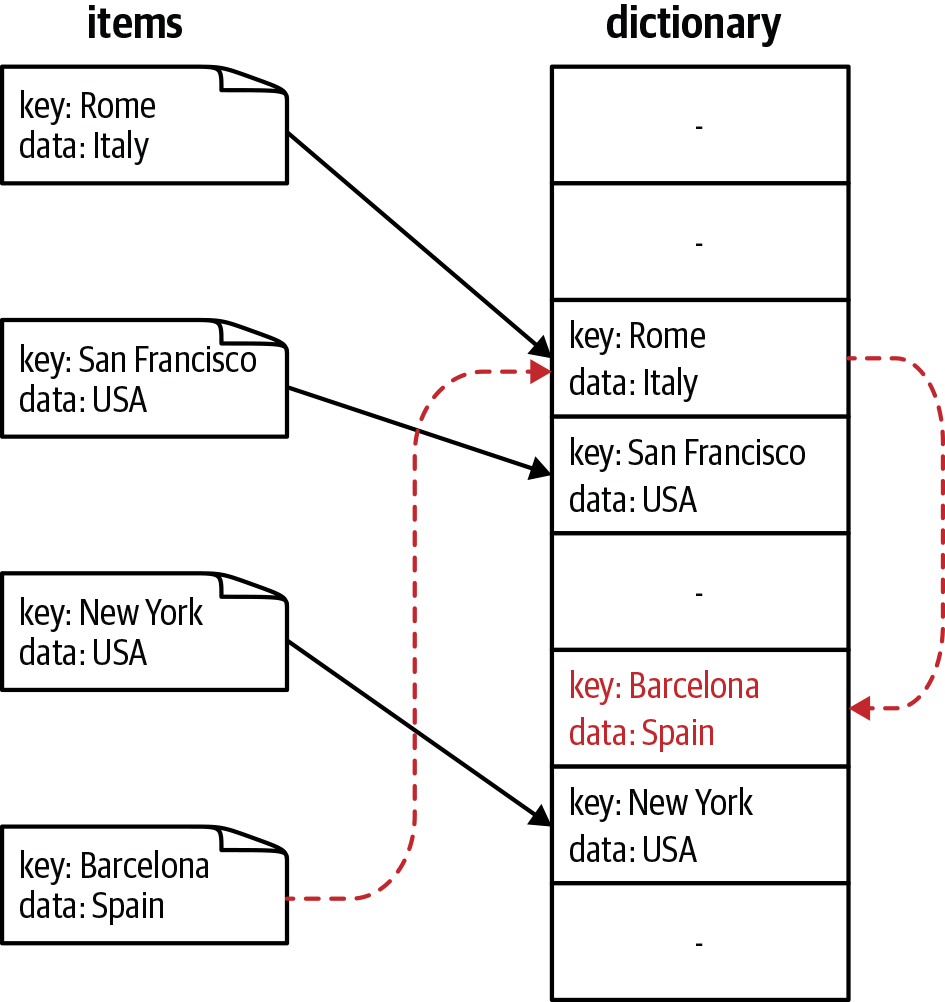

图。插入时产生的哈希表发生冲突

插入密钥会导致冲突，并使用示例中的方案计算新索引 4-4. 也可以使用示例中的代码在Python中创建此字典 4-5.

例4-5。自定义哈希函数

In [28]:
class City(str):
    def __hash__(self):
        return ord(self[0])


if __name__ == "__main__":
    print(
        "Adding Rome, San Francisco, New York and Barcelona to a set.  New York and Barcenlona will collide!"
    )
    # We create a dictionary where we assign arbitrary values to cities
    data = {
        City("Rome"): "Italy",
        City("San Francisco"): "USA",
        City("New York"): "USA",
        City("Barcelona"): "Spain",
    }

Adding Rome, San Francisco, New York and Barcelona to a set.  New York and Barcenlona will collide!


在本例中，Barcelona 和 Rome 导致哈希冲突（上图显示了插入的结果）。我们看到这一点是因为，对于包含四个元素的字典，掩码值为0b111。因此，Barcelona 和 Rome将尝试使用相同的指数：

练习

解决以下问题。哈希冲突的讨论如下：
- 使用示例中创建的字典查找元素 4-5，查找键是什么样子的？将检查哪些指标？
- 使用示例中创建的字典删除元素 4-5，你怎么处理删除密钥的问题？接下来如何查找罗马和巴塞罗那的钥匙？
- 考虑示例中创建的字典的哈希冲突 4-5，如果将500个城市的名字都以大写字母开头，添加到一个哈希表中，您预计会发生多少哈希冲突？1000个城市怎么样？你能想出降低碰撞次数的方法吗？

对于500个城市，大约有474个字典元素与以前的值（500–26）发生冲突，每个哈希值有500/26=19.2个城市与之关联。对于1000个城市，974个元素将发生碰撞，每个散列将有1000/26=38.4个城市与其关联。这是因为散列仅仅基于第一个字母的数值，它只能从a–Z中取一个值，只允许26个独立的散列值。这意味着此表中的查找可能需要多达38次后续查找才能找到正确的值。为了解决这个问题，我们必须通过考虑散列中城市的其他方面来增加可能的散列值的数量。字符串上的默认哈希函数考虑每个字符，以便最大化可能值的数量。有关更多说明，请参阅“哈希函数和熵”。

### 删除

当从哈希表中删除一个值时，我们不能简单地将空值写入该内存桶。这是因为我们在探测散列冲突时使用了NULLs作为sentinel值。因此，我们必须编写一个表示bucket为空的特殊值，但在解决哈希冲突时，它后面可能还有一些值需要考虑。因此，如果从字典中删除了“Rome”，那么随后对“Barcelona”的查找将首先看到“Rome”原来所在的哨兵值，而不是停止，而是继续检查由索引\u序列给出的下一个索引。这些空槽可以在将来写入，并在调整哈希表大小时删除。

### 调整大小

当哈希表中插入更多的项时，必须调整表本身的大小以容纳它们。可以证明，一个不超过三分之二满的表将具有最佳的空间节省，同时仍然对预期的冲突数有一个很好的界限。因此，当一个表达到这个临界点时，它就增长了。为此，分配一个更大的表（即在内存中保留更多的bucket），调整掩码以适应新表，并将旧表的所有元素重新插入新表中。这需要重新计算索引，因为更改的掩码将更改生成的索引。因此，调整大型哈希表的大小可能会非常昂贵！但是，由于我们只在表太小的时候才进行调整大小操作，而不是每次插入时都进行调整，因此插入的分摊成本仍然是O（1）

默认情况下，字典或集合的最小大小是8（也就是说，如果只存储三个值，Python仍将分配八个元素），它将按3调整大小× 如果字典超过三分之二满。因此，一旦第六项被插入到原来的空字典中，它将被调整大小以容纳18个元素。此时，一旦将第13个元素插入到对象中，它的大小将调整为39，然后调整为81，依此类推，始终将大小增加3× (我们将在“哈希函数和熵”中解释如何计算字典的大小。这提供了以下可能的尺寸：

需要注意的是，调整大小可能会使哈希表变大或变小。也就是说，如果一个哈希表中有足够多的元素被删除，则该表的大小可以缩小。但是，调整大小仅在插入过程中发生。

### 散列函数与熵

Python中的对象通常是可散列的，因为它们已经有了与之相关联的内置散列函数  `__hash__` 和函数 `__cmp__` 。对于数字类型（int和float），散列仅基于它们所表示的数字的位值。元组和字符串具有基于其内容的哈希值。另一方面，列表不支持哈希，因为它们的值可以更改。由于列表的值可以更改，因此表示该列表的哈希也可以更改，这将更改该键在哈希表中的相对位置

用户定义的类也有默认的哈希和比较函数。默认的散列函数只返回对象在内存中的位置，由内置的id函数给出。类似地，cmp操作符比较对象在内存中的位置的数值。

这通常是可以接受的，因为一个类的两个实例通常是不同的，不应该在哈希表中发生冲突。但是，在某些情况下，我们希望使用set或dict对象来消除项目之间的歧义。采用以下类定义：

In [30]:
class Point(object):
    def __init__(self, x, y):
        self.x, self.y = x, y

如果我们要实例化多个具有相同x和y值的点对象，它们在内存中都是独立的对象，因此在内存中有不同的位置，这将为它们提供不同的散列值。这意味着将它们全部放入一个集合将导致它们都有单独的条目：

In [31]:
p1 = Point(1, 1)
p2 = Point(1, 1)
points = set([p1, p2])

In [32]:
Point(1,1) in set([p1, p2])

False

In [33]:
class Point(object):
    def __init__(self, x, y):
        self.x, self.y = x, y

    def __hash__(self):
        return hash((self.x, self.y))

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

这允许我们在集合或字典中创建按点对象的属性而不是实例化对象的内存地址编制索引的条目：

In [34]:
p1 = Point(1,1)
p2 = Point(1,1)
set([p1, p2])

{<__main__.Point at 0x3eaa7c8>}

In [35]:
Point(1, 1) in set([p1, p2])

True

正如我们在讨论散列冲突时提到的，自定义选定的散列函数应该小心地均匀分布散列值，以避免冲突。有许多冲突会降低哈希表的性能：如果大多数键都有冲突，我们需要不断地“探测”其他值，有效地遍历字典中可能存在的很大一部分来找到有问题的键。在最坏的情况下，当字典中的所有键发生冲突时，字典中的查找性能为O（n），因此与在列表中搜索时的性能相同。

如果我们知道我们在一个字典中存储了5000个值，并且我们需要为我们希望用作键的对象创建一个哈希函数，那么我们必须知道字典将存储在一个大小为163847的哈希表中，因此只有哈希表的最后14位被用来创建索引（对于这个大小的哈希表，掩码为bin（16_-1）=0b11111111）。

“我的散列函数分布得有多均匀”这个概念被称为散列函数的熵。熵的定义是

$$S = -\sum_{i}^{}p(i)\cdot log(p(i))$$

其中p（i）是散列函数给出散列i的概率。当每个散列值被选择的概率相等时，它被最大化。最大化熵的散列函数称为理想散列函数，因为它保证了最小的冲突次数。

对于无限大的字典，用于整数的哈希函数是理想的。这是因为整数的哈希值就是整数本身！对于无限大的字典，掩码值是无限的，因此我们考虑哈希值中的所有位。因此，给定任意两个数字，我们可以保证它们的哈希值不会相同。

然而，如果我们把这本词典定为有限的，我们就不能再得到这种保证了。例如，对于包含四个元素的字典，我们使用的掩码是0b111。因此，数字5的哈希值为5 & 0b111=5，501的哈希值为501 & 0b111=5，因此它们的条目将发生冲突。

在使用有限字典时，没有一个最佳哈希函数可供使用。但是，预先知道将使用的值的范围以及字典的大小有助于做出正确的选择。例如，如果我们将两个小写字母的所有676个组合作为键存储在字典（aa、ab、ac等）中，那么一个好的散列函数就是示例中所示的函数 4-6.

例4-6。最优二字母哈希函数

In [36]:
def twoletter_hash(key):
    offset = ord('a')
    k1, k2 = key
    return (ord(k2) - offset) + 26 * (ord(k1) - offset)

考虑到掩码为0b1111111111（676个值的字典将保存在长度为2048的哈希表中，该哈希表的掩码为bin（2048-1）=0b11111111），因此这不会对两个小写字母的任何组合产生哈希冲突。

例子 4-7非常明确地展示了对用户定义类使用错误哈希函数的后果，错误哈希函数的代价（事实上，它是最糟糕的哈希函数！）是41.8× 查找速度减慢。

例4-7。好的散列函数和坏的散列函数之间的时间差

In [37]:
import string
import timeit

class BadHash(str):
    def __hash__(self):
        return 42

class GoodHash(str):
    def __hash__(self):
        """
        This is a slightly optimized version of twoletter_hash
        """
        return ord(self[1]) + 26 * ord(self[0]) - 2619

baddict = set()
gooddict = set()
for i in string.ascii_lowercase:
    for j in string.ascii_lowercase:
        key = i + j
        baddict.add(BadHash(key))
        gooddict.add(GoodHash(key))

badtime = timeit.repeat(
    "key in baddict",
    setup = "from __main__ import baddict, BadHash; key = BadHash('zz')",
    repeat = 3,
    number = 1_000_000,
)
goodtime = timeit.repeat(
    "key in gooddict",
    setup = "from __main__ import gooddict, GoodHash; key = GoodHash('zz')",
    repeat = 3,
    number = 1_000_000,
)

print(f"Min lookup time for baddict: {min(badtime)}")
print(f"Min lookup time for gooddict: {min(goodtime)}")

Min lookup time for baddict: 22.924795043999893
Min lookup time for gooddict: 0.5077672709999206


练习

1. 说明对于无限字典（以及无限掩码），使用整数的值作为其哈希不会产生冲突。
2. 显示示例中给出的哈希函数 4-6非常适合大小为1024的哈希表。为什么它不适合较小的哈希表？

## 字典和命名空间

查字典很快；但是，不必要地这样做会降低代码的速度，就像任何无关的行一样。Python的名称空间管理（namespace management）中有一个地方可以看到这一点，它大量使用字典进行查找。
无论何时在Python中调用变量、函数或模块，都有一个层次结构来确定在何处查找这些对象。首先，Python查看locals（）数组，该数组包含所有局部变量的条目。Python致力于快速查找局部变量，这是链中唯一不需要字典查找的部分。如果不存在，则搜索globals（）字典。最后，如果在那里找不到对象，则搜索 `__builtin__` 对象。需要注意的是，虽然locals（）和globals（）是显式字典，而且从技术上讲，`__builtin__` 在为给定属性搜索内置时，我们只是在它的locals（）映射中进行字典查找（所有模块对象和类对象都是这样！）。

为了更清楚地说明这一点，让我们看一个调用在不同作用域中定义的函数的简单示例（例如 4-8). 我们可以用dis模块分解函数（例如 4-9）以更好地了解这些命名空间查找是如何发生的（请参阅“使用dis模块检查CPython字节码”）。

例4-8。命名空间查找

In [38]:
import math
from math import sin


def test1(x):
    """
    >>> %timeit test1(123_456)
    162 µs ± 3.82 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
    """
    res = 1
    for _ in range(1000):
        res += math.sin(x)
    return res


def test2(x):
    """
    >>> %timeit test2(123_456)
    124 µs ± 6.77 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
    """
    res = 1
    for _ in range(1000):
        res += sin(x)
    return res


def test3(x, sin=math.sin):
    """
    >>> %timeit test3(123_456)
    105 µs ± 3.35 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
    """
    res = 1
    for _ in range(1000):
        res += sin(x)
    return res


例4-9。命名空间查找已反汇编

In [40]:
import dis
dis.dis(test1)

 10           0 LOAD_CONST               1 (1)
              2 STORE_FAST               1 (res)

 11           4 SETUP_LOOP              30 (to 36)
              6 LOAD_GLOBAL              0 (range)
              8 LOAD_CONST               2 (1000)
             10 CALL_FUNCTION            1
             12 GET_ITER
        >>   14 FOR_ITER                18 (to 34)
             16 STORE_FAST               2 (_)

 12          18 LOAD_FAST                1 (res)
             20 LOAD_GLOBAL              1 (math)
             22 LOAD_METHOD              2 (sin)
             24 LOAD_FAST                0 (x)
             26 CALL_METHOD              1
             28 INPLACE_ADD
             30 STORE_FAST               1 (res)
             32 JUMP_ABSOLUTE           14
        >>   34 POP_BLOCK

 13     >>   36 LOAD_FAST                1 (res)
             38 RETURN_VALUE


第一个函数test1通过显式查看数学库来调用sin。这在生成的字节码中也很明显：首先必须加载对数学模块的引用，然后在此模块上执行属性查找，直到最终获得对sin函数的引用。这是通过两个字典查找完成的：一个查找数学模块，另一个查找模块内的sin函数。

In [41]:
dis.dis(test2)

 21           0 LOAD_CONST               1 (1)
              2 STORE_FAST               1 (res)

 22           4 SETUP_LOOP              28 (to 34)
              6 LOAD_GLOBAL              0 (range)
              8 LOAD_CONST               2 (1000)
             10 CALL_FUNCTION            1
             12 GET_ITER
        >>   14 FOR_ITER                16 (to 32)
             16 STORE_FAST               2 (_)

 23          18 LOAD_FAST                1 (res)
             20 LOAD_GLOBAL              1 (sin)
             22 LOAD_FAST                0 (x)
             24 CALL_FUNCTION            1
             26 INPLACE_ADD
             28 STORE_FAST               1 (res)
             30 JUMP_ABSOLUTE           14
        >>   32 POP_BLOCK

 24     >>   34 LOAD_FAST                1 (res)
             36 RETURN_VALUE


In [42]:
dis.dis(test3)

 32           0 LOAD_CONST               1 (1)
              2 STORE_FAST               2 (res)

 33           4 SETUP_LOOP              28 (to 34)
              6 LOAD_GLOBAL              0 (range)
              8 LOAD_CONST               2 (1000)
             10 CALL_FUNCTION            1
             12 GET_ITER
        >>   14 FOR_ITER                16 (to 32)
             16 STORE_FAST               3 (_)

 34          18 LOAD_FAST                2 (res)
             20 LOAD_FAST                1 (sin)
             22 LOAD_FAST                0 (x)
             24 CALL_FUNCTION            1
             26 INPLACE_ADD
             28 STORE_FAST               2 (res)
             30 JUMP_ABSOLUTE           14
        >>   32 POP_BLOCK

 35     >>   34 LOAD_FAST                2 (res)
             36 RETURN_VALUE


最后，test3将sin函数定义为关键字参数，其默认值是对数学模块中sin函数的引用。虽然我们仍然需要在模块中找到对该函数的引用，但只有在第一次定义test3函数时才有必要这样做。之后，对sin函数的引用以默认关键字参数的形式作为局部变量存储在函数定义中。如前所述，局部变量不需要字典查找；它们存储在一个非常小的数组中，具有非常快的查找时间。因此，找到函数的速度相当快！

虽然这些效果是Python中名称空间管理方式的一个有趣结果，但test3绝对不是“Pythonic”的。幸运的是，这些额外的字典查找只有在被大量调用时（即在非常快的循环的最内部块中，如Julia集示例中）才会开始降低性能。记住这一点，一个更具可读性的解决方案是在循环开始之前用全局引用设置一个局部变量。我们仍然需要在每次调用函数时进行一次全局查找，但是在循环中对该函数的所有调用都会更快。这说明了这样一个事实：如果代码被运行数百万次，即使是代码中微小的慢化也会被放大。即使一个字典查找本身可能只需要几百纳秒，如果我们在这个查找上循环数百万次，这些纳秒可以很快加起来。

## 小结

# 迭代器和生成器

本节结束后您将能够回答的问题
- 生成器如何节省内存？
- 什么时候使用生成器最好？
- 如何使用itertools创建复杂的生成器工作流？
- 惰性评估什么时候有益，什么时候没有益？

当许多有其他语言经验的人开始学习Python时，for循环表示法的差异让他们大吃一惊。也就是说，不是写作:

它们被引入一个名为range的新函数：

在Python代码示例中，我们似乎调用了一个函数range，它创建了for循环继续所需的所有数据。直观地说，这可能是一个相当耗时的过程，如果我们试图在数字1到100000000之间循环，那么我们需要花费大量时间来创建该数组！然而，这正是生成器发挥作用的地方：它们本质上允许我们懒散地评估这类函数，这样我们就可以在不影响性能的情况下获得这些特殊用途函数的代码可读性。

为了理解这个概念，让我们实现一个函数，通过填充列表和使用生成器来计算几个斐波那契数：

In [45]:
import timeit


def fibonacci_list(num_items):
    numbers = []
    a, b = 0, 1
    while len(numbers) < num_items:
        numbers.append(a)
        a, b = b, a + b
    return numbers


def fibonacci_gen(num_items):
    a, b = 0, 1
    while num_items:
        yield a #此函数将产生多个值，而不是返回一个值。这将把这个常规函数转换成一个生成器，可以重复轮询下一个可用值。
        a, b = b, a + b
        num_items -= 1
        
def test_fibonacci(func, N):
    for i in func(N):
        pass


if __name__ == "__main__":
    setup = "from __main__ import " "(test_fibonacci, fibonacci_gen, fibonacci_list, N)"
    iterations = 1000

    for N in (2, 100, 1_000, 100_00):
        t = timeit.timeit(
            stmt=f"test_fibonacci(fibonacci_list, N)", setup=setup, number=iterations
        )
        print(
            f"fibonacci_list took {t / iterations:.5e}s to calculate {N} fibonacci numbers"
        )

        t = timeit.timeit(
            stmt=f"test_fibonacci(fibonacci_gen, N)", setup=setup, number=iterations
        )
        print(
            f"fibonacci_gen took {t / iterations:.5e}s to calculate {N} fibonacci numbers"
        )


fibonacci_list took 9.24567e-07s to calculate 2 fibonacci numbers
fibonacci_gen took 8.07071e-07s to calculate 2 fibonacci numbers
fibonacci_list took 2.31457e-05s to calculate 100 fibonacci numbers
fibonacci_gen took 1.65974e-05s to calculate 100 fibonacci numbers
fibonacci_list took 2.54039e-04s to calculate 1000 fibonacci numbers
fibonacci_gen took 2.00436e-04s to calculate 1000 fibonacci numbers
fibonacci_list took 6.15317e-03s to calculate 10000 fibonacci numbers
fibonacci_gen took 3.66523e-03s to calculate 10000 fibonacci numbers


首先要注意的是，fibonacci\u列表实现必须创建并存储所有相关fibonacci数的列表。因此，如果我们想得到序列中的10000个数字，函数将在数字列表中添加10000个附加项（正如我们在第章中讨论的那样） 3，具有与之相关联的开销），然后返回它。

另一方面，生成器能够“返回”许多值。每次代码到达yield时，函数都会发出它的值，当请求另一个值时，函数会恢复运行（保持以前的状态）并发出新的值。当函数结束时，抛出StopIteration异常，指示给定的生成器没有更多的值。因此，即使这两个函数最终都必须执行相同数量的计算，前面循环的fibonacci_list版本使用10000× 更多内存（或num_items乘以更多内存）。

记住这段代码，我们可以分解使用fibonacci_list和fibonacci_gen实现的for循环。这意味着我们必须能够从要循环的对象中创建迭代器。为了从几乎任何对象创建迭代器，我们可以使用Python内置的iter函数。此函数用于列表、元组、字典和集合，返回对象中项或键的迭代器。对于更复杂的对象，iter返回该对象的 `_iter_` 属性的结果。由于fibonacci_gen已经返回了一个迭代器，因此对它调用iter是一个简单的操作，它返回原始对象（因此type（fibonacci_gen（10））==type（iter（fibonacci_gen（10）））。但是，由于fibonacci_list返回一个list，我们必须创建一个新对象，一个list迭代器，它将遍历list中的所有值。通常，一旦创建了迭代器，我们就用它调用next（）函数，检索新值，直到抛出StopIteration异常。这为我们提供了一个很好的for循环解构视图，如示例所示 5-1.

例5-1。Python for loop解构

for循环代码表明，在使用fibonacci_list而不是fibonacci_gen时，我们正在做额外的工作来调用iter；然而，对于fibonacci_list，我们需要分配一个新的列表并预计算它的值，然后我们仍然必须创建一个迭代器。

更重要的是，预先计算fibonacci_list需要为完整的数据集分配足够的空间，并将每个元素设置为正确的值，尽管我们总是一次只需要一个值。这也使得列表分配无用。事实上，它甚至可能使循环无法运行，因为它可能试图分配比可用内存更多的内存（fibonacci_list（100_000_000）将创建一个3.1 GB的大列表！）。通过对结果进行计时，我们可以非常清楚地看到：

In [46]:
def test_fibonacci_list():
    """
    >>> %timeit test_fibonacci_list()
    332 ms ± 13.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

    >>> %memit test_fibonacci_list()
    peak memory: 492.82 MiB, increment: 441.75 MiB
    """
    for i in fibonacci_list(100_000):
        pass


def test_fibonacci_gen():
    """
    >>> %timeit test_fibonacci_gen()
    126 ms ± 905 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)

    >>> %memit test_fibonacci_gen()
    peak memory: 51.13 MiB, increment: 0.00 MiB
    """
    for i in fibonacci_gen(100_000):
        pass

正如我们所看到的，与fibonacci_list的441mb相比，generator版本的速度快了一倍多，而且不需要可测量的内存。在这一点上，您似乎应该到处使用生成器来代替创建列表，但这会造成许多复杂的问题。

举个例子，如果你需要多次引用斐波那契数列呢？在这种情况下，fibonacci_list将提供这些数字的预计算列表，而fibonacci_gen将不得不一遍又一遍地重新计算它们。一般来说，改变使用生成器而不是预先计算的数组需要算法上的改变，而这些改变有时并不那么容易理解。

在源代码中经常看到的一个简单示例是使用生成器创建一个数字序列，只使用列表理解来计算结果的长度：

当我们仍然使用fibonacci生成fibonacci序列作为生成器时，我们将所有可被3整除的值保存到一个数组中，只取该数组的长度，然后丢弃数据。在这个过程中，我们无缘无故地消耗了86MB的数据。2事实上，如果我们在一个足够长的斐波那契序列中这样做，前面的代码将无法运行，因为内存问题，即使计算本身非常简单！

回想一下，我们可以使用`[<value>for<item>in<sequence>if<condition>]`形式的语句来创建列表理解。这将创建所有<value>项的列表。或者，我们可以使用类似的语法来创建<value>项的生成器，而不是使用（ `<value>for<item>in<sequence>if<condition>` ）的列表。
    
利用列表理解和生成器理解之间的细微差别，我们可以优化前面的代码，使之可以被3整除。但是，生成器没有长度属性。因此，我们必须聪明一点：

在这里，我们有一个生成器，每当它遇到一个可以被3整除的数时，它就会发出一个值1的信号，否则什么都不会。通过对这个生成器中的所有元素求和，我们基本上与列表理解版本相同，并且不消耗任何重要的内存。

对于这些较小的序列长度，这两个版本的代码的性能几乎相当，但是生成器版本对内存的影响远远小于列表理解。此外，我们将列表版本转换为一个生成器，因为对于列表中的每个元素来说，重要的是它的当前值，无论这个数字是否可以被3整除；它在数字列表中的位置或上一个/下一个值是什么并不重要。更复杂的函数也可以转换为生成器，但这取决于它们对状态的依赖性，这可能成为一件困难的事情。

## 无穷级数的迭代器

In [47]:
def fibonacci():
    i, j = 0, 1
    while True:
        yield j
        i, j = j, i + j

在这段代码中，我们正在做一些以前的 `fibonacci_list` 代码不可能做到的事情：我们正在将一系列无限的数字封装到一个函数中。这允许我们从这个流中获取任意多的值，并在代码认为已经足够时终止。

生成器没有得到充分利用的一个原因是，生成器中的许多逻辑可以封装在逻辑代码中。生成器实际上是一种组织代码和生成更智能循环的方法。例如，我们可以用多种方式回答“5000以下有多少斐波那契数是奇数”的问题：

In [48]:
def fibonacci_naive():
    i, j = 0, 1
    count = 0
    while j <= 5000:
        if j % 2:
            count += 1
        i, j = j, i + j
    return count

def fibonacci_transform():
    count = 0
    for f in fibonacci():
        if f > 5000:
            break
        if f % 2:
            count += 1
    return count

from itertools import takewhile
def fibonacci_succinct():
    first_5000 = takewhile(lambda x: x <= 5000,
                           fibonacci())
    return sum(1 for x in first_5000
               if x % 2)

所有这些方法都具有相似的运行时属性（通过内存占用和运行时性能来衡量），但是`fibonacci_transform`函数从以下几个方面受益。首先，它比`fibonacci_succinct` 简洁得多，这意味着其他开发人员很容易调试和理解它。后者主要是对下一节的警告，在下一节中我们将介绍一些使用itertools的常见工作流，而该模块使用迭代器大大简化了许多简单操作，它还可以快速地使Python代码变得非常不Pythonic。相反，`fibonacci_naive` 是一次做多件事情，这隐藏了它正在做的实际计算！虽然在生成函数中我们迭代斐波那契数是很明显的，但我们并没有被实际的计算过多地编号。最后，`fibonacci_transform`更具推广性。此函数可以重命名为`num_odd_under_5000`，并通过参数接收生成器，从而处理任何序列。

`fibonacci_transform`和`fibonacci_succinct`函数的另一个好处是，它们支持计算中有两个阶段的概念：生成数据和转换数据。这些函数非常清楚地对数据执行转换，而斐波那契函数生成数据。这种划分增加了额外的清晰度和功能性：我们可以移动一个转换函数来处理一组新的数据，或者对现有数据执行多个转换。在创建复杂的程序时，这个范例一直很重要；但是，生成器通过使生成器负责创建数据和对生成的数据进行操作的正常函数来促进这一点。

## 惰性生成器评估

如前所述，使用生成器获得内存好处的方法是只处理当前感兴趣的值。在使用生成器进行计算的任何时候，我们只有当前值，不能引用序列中的任何其他项（以这种方式执行的算法通常称为单通或在线）。这有时会使生成器更难使用，但许多模块和函数都有帮助。

主要的兴趣库是标准库中的itertools。它提供了许多其他有用的功能，包括：

- islice

允许对潜在的无限生成器进行切片
- chain

把多生成器连在一起

- takewhile

添加结束生成器的条件

- cycle

通过不断重复，使有限生成器无限大

让我们建立一个使用生成器分析大型数据集的示例。假设我们有一个分析程序，对时间数据进行分析，每秒一个数据，在过去的20年中，这是631152000个数据点！数据存储在一个文件中，每行一秒钟，我们无法将整个数据集加载到内存中。因此，如果我们想做一些简单的异常检测，我们必须使用生成器来节省内存！

问题是：给定一个格式为“timestamp，value”的数据文件，找出值不同于正态分布的天数。我们首先编写代码，逐行读取文件，并将每行的值作为Python对象输出。我们还将创建一个`read_fake_data` 生成器来生成假数据，我们可以用它来测试我们的算法。对于这个函数，我们仍然采用参数filename，以便与`read_data` 具有相同的函数签名；然而，我们将忽略它。这两个函数如示例所示 我们读取文件中的下一行，或者生成新的伪数据，只有在调用next（）函数时。

例5-2。惰性读取数据

In [53]:
from datetime import datetime
from itertools import count, filterfalse, groupby, islice
from random import normalvariate, randint

from scipy.stats import normaltest


def read_data(filename):
    with open(filename) as fd:
        for line in fd:
            data = line.strip().split(",")
            timestamp, value = map(int, data)
            yield datetime.fromtimestamp(timestamp), value


def read_fake_data(filename):
    for timestamp in count():
        #  We insert an anomalous data point approximately once a week
        if randint(0, 7 * 60 * 60 * 24 - 1) == 1:
            value = normalvariate(0, 1)
        else:
            value = 100
        yield datetime.fromtimestamp(timestamp), value

现在我们要创建一个函数来输出在同一天发生的数据组。为此，我们可以在itertools中使用groupby函数（例如 5-3). 此函数的工作方式是接收项目序列和用于对这些项目进行分组的键。输出是生成元组的生成器，元组的项是组的键，而生成元组中的项。作为我们的关键功能，我们将输出记录数据的日历日。这个“键”函数可以是任何我们可以按小时、按年份或按实际值中的某些属性对数据进行分组的函数。唯一的限制是，只能为顺序数据组成组。所以如果我们有输入A，按字母分组，我们会得到三个组：`（A，[A，A，A，A]），（B，[B，B]），和（A，[A，A]）`。

例5-3。分组我们的数据

In [50]:
from itertools import groupby

def groupby_day(iterable):
    key = lambda row: row[0].day
    for day, data_group in groupby(iterable, key):
        yield list(data_group)

现在做实际的异常检测。我们在示例中这样做 5-4通过创建一个函数，给定一组数据，返回它是否遵循正态分布（使用scipy.stats.normaltest）。我们可以将此检查与itertools.filterfalse一起使用，只对未通过测试的输入过滤完整的数据集。这些输入是我们认为不正常的。

In [51]:
from scipy.stats import normaltest
from itertools import filterfalse

def is_normal(data, threshold=1e-3):
    _, values = zip(*data)
    k2, p_value = normaltest(values)
    if p_value < threshold:
        return False
    return True

def filter_anomalous_groups(data):
    yield from filterfalse(is_normal, data)

最后，我们可以将生成器链放在一起，以获得具有异常数据的日期（例如 5-5).

例5-5。把我们的生成器连在一起

In [54]:
def filter_anomalous_groups(data):
    yield from filterfalse(is_normal, data)


def filter_anomalous_data(data):
    data_group = groupby_day(data)
    yield from filter_anomalous_groups(data_group)


if __name__ == "__main__":
    data = read_fake_data("fake_filename")
    anomaly_generator = filter_anomalous_data(data)
    first_five_anomalies = islice(anomaly_generator, 5)

    for data_anomaly in first_five_anomalies:
        start_date = data_anomaly[0][0]
        end_date = data_anomaly[-1][0]
        print(f"Anomaly from {start_date} - {end_date}")


Anomaly from 1970-01-01 08:00:00 - 1970-01-01 23:59:59
Anomaly from 1970-01-02 00:00:00 - 1970-01-02 23:59:59
Anomaly from 1970-01-03 00:00:00 - 1970-01-03 23:59:59
Anomaly from 1970-01-04 00:00:00 - 1970-01-04 23:59:59
Anomaly from 1970-01-05 00:00:00 - 1970-01-05 23:59:59


这种方法允许我们获得异常天数的列表，而不必加载整个数据集。只有足够的数据被读取来产生前五个异常。此外，可以进一步读取异常生成器对象以继续检索异常数据这称为延迟求值—仅执行显式请求的计算，如果存在提前终止条件，则可以大幅减少总体运行时间。

用这种方式组织分析的另一个好处是，它允许我们轻松地进行更广泛的计算，而不必重新编写大部分代码。例如，如果我们希望有一个一天的移动窗口，而不是按天分组，我们可以在示例中替换 groupby_day 5-3类似这样：

In [55]:
from datetime import datetime

def groupby_window(data, window_size=3600):
    window = tuple(islice(data, window_size))
    for item in data:
        yield window
        window = window[1:] + (item,)

在这个版本中，我们还非常明确地看到了这个方法和前面的方法的内存保证，它将只存储窗口的数据作为状态（在这两种情况下，一天或3600个数据点）。请注意，for循环检索到的第一项是window_size-th值。这是因为数据是一个迭代器，在前一行中，我们使用了第一个窗口大小值。

最后一点注意：在groupby_window函数中，我们不断地创建新的元组，用数据填充它们，并将它们提供给调用者。通过使用collections模块中的deque对象，我们可以极大地优化这一点。这个对象给我们O（1）个在列表开头或结尾的追加和删除（而普通列表是O（1）个在列表结尾的追加或删除，O（n）个在列表开头的相同操作）。使用deque对象，我们可以将新数据附加到列表的右侧（或结尾），并使用deque.popleft（）从列表的左侧（或开头）删除数据，而无需分配更多空间或执行长O（n）操作。但是，我们必须就地处理deque对象，并将以前的视图销毁到滚动窗口（有关就地操作的更多信息，请参阅“内存分配和就地操作”）。解决这个问题的唯一方法是将数据复制到元组中，然后将其返回给调用者，这样就消除了更改带来的任何好处！

## 小结

通过用迭代器构造我们的异常发现算法，我们可以处理比内存多得多的数据。更重要的是，我们可以做得比使用列表更快，因为我们避免了所有昂贵的附加操作。

由于迭代器是Python中的一种基本类型，因此这应该始终是一种尝试减少应用程序内存占用的方法。这样做的好处是，结果是延迟评估的，因此您只处理所需的数据，并且节省了内存，因为除非明确要求，否则我们不会存储以前的结果。在第章 11.我们将讨论可用于更具体问题的其他方法，并介绍一些在RAM出现问题时看待问题的新方法。

使用迭代器解决问题的另一个好处是，它可以让您的代码在多个CPU或多台计算机上使用，我们将看到这一点。正如我们在“无限级数迭代器”中所讨论的，在使用迭代器时，必须始终考虑算法工作所需的各种状态。一旦你弄清楚如何打包算法运行所需的状态，它在哪里运行就不重要了。我们可以看到这种范例，例如，多处理和iPython模块，它们都使用类似于map的函数来启动并行任务。